##libraries

In [1]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import pyarrow.parquet as pq
import pandas as pd
import re

import numpy as np
from scipy.stats import zscore
from scipy.stats import skew, kurtosis


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
local_files_directory = '/content/drive/MyDrive/MITBDS/parquet_files_prepared'
parquet_files_paths = glob.glob(os.path.join(local_files_directory, 'yellow_tripdata_*.parquet'))
parquet_files_paths = sorted(parquet_files_paths)

### check which files exist

In [ ]:
drive_folder_path = '/content/drive/MyDrive/MITBDS/parquet_files_prepared'

if os.path.exists(drive_folder_path):
    parquet_files_in_drive = [f for f in os.listdir(drive_folder_path) if f.endswith('.parquet')]

    print(f"Found {len(parquet_files_in_drive)} .parquet files in '{drive_folder_path}':")
    for f in parquet_files_in_drive[:10]:
        print(f"- {f}")
    if len(parquet_files_in_drive) > 10:
        print(f"... and {len(parquet_files_in_drive) - 10} more files.")
else:
    print(f"Error: The folder '{drive_folder_path}' does not exist.")


Found 143 .parquet files in '/content/drive/MyDrive/MITBDS/parquet_files_prepared':
- yellow_tripdata_2014-02.parquet
- yellow_tripdata_2014-03.parquet
- yellow_tripdata_2014-05.parquet
- yellow_tripdata_2014-01.parquet
- yellow_tripdata_2014-06.parquet
- yellow_tripdata_2014-07.parquet
- yellow_tripdata_2014-08.parquet
- yellow_tripdata_2014-09.parquet
- yellow_tripdata_2014-10.parquet
- yellow_tripdata_2014-04.parquet
... and 133 more files.


## column name consistency

In [ ]:
column_name_variations = {}
all_processed_columns = set()

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        schema = pq.read_schema(file_path)
        file_columns = set(schema.names)

        all_processed_columns.update(file_columns)

        for col in file_columns:
            normalized_col = col.lower()
            if normalized_col not in column_name_variations:
                column_name_variations[normalized_col] = set()
            column_name_variations[normalized_col].add(col)

    except Exception as e:
        print(f"Could not read schema for {file_name}, error: {e}")

inconsistent_columns = {}
for normalized_name, original_names in column_name_variations.items():
    if len(original_names) > 1:
        inconsistent_columns[normalized_name] = sorted(list(original_names))


if inconsistent_columns:
    print("\nFound inconsistencies:")
    for normalized_name, variations in inconsistent_columns.items():
        print(f"- Normalized '{normalized_name}': Found variations {variations}")

else:
    print("\nNo inconsistencies.")


No column name inconsistencies.


#### renaming airport_fee

In [ ]:
edited_files_count = 0
files_with_airport_fee = []


for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        schema = pq.read_schema(file_path)
        if 'Airport_fee' in schema.names:
            print(f"Found 'Airport_fee' in {file_name}. Renaming...")
            df = pd.read_parquet(file_path)
            df = df.rename(columns={'Airport_fee': 'airport_fee'})
            df.to_parquet(file_path, index=False)
            edited_files_count += 1
            files_with_airport_fee.append(file_name)
            print(f"Successfully renamed column in {file_name}")
        else:
            pass

    except Exception as e:
        print(f"Error processing {file_name}: {e}")

## missing values

In [ ]:
local_files_directory = '/content/drive/MyDrive/MITBDS/parquet_files'
parquet_files_paths = glob.glob(os.path.join(local_files_directory, 'yellow_tripdata_*.parquet'))
parquet_files_paths = sorted(parquet_files_paths)

if not parquet_files_paths:
    print("No files.")
else:
    all_missing_data = []

    for file_path in parquet_files_paths:
        file_name = os.path.basename(file_path)
        try:
            df = pd.read_parquet(file_path)
            missing_counts = df.isnull().sum()
            missing_counts = missing_counts[missing_counts > 0]

            if not missing_counts.empty:
                for col, count in missing_counts.items():
                    all_missing_data.append({
                        'File': file_name,
                        'Column': col,
                        'Missing Count': count,
                        'Total Rows': len(df),
                        'Missing Percentage': (count / len(df)) * 100
                    })
            del df
        except Exception as e:
            print(f"Could not process {file_name}, error: {e}")

    if all_missing_data:
        missing_df = pd.DataFrame(all_missing_data)

        print("\nMissing Values:")
        display(missing_df)

        print("\nMissing Value Summ")
        summary_by_column = missing_df.groupby('Column').agg(
            TotalMissingCount=('Missing Count', 'sum'),
            NumFilesAffected=('File', 'nunique'),
            AvgMissingPercentage=('Missing Percentage', 'mean')
        ).sort_values(by='TotalMissingCount', ascending=False)

        display(summary_by_column)

        print(f"\nTotal files processed: {len(parquet_files_paths)}")
    else:
        print("\nNo missing values")


Missing Values per File and Column:


,File,Column,Missing Count,Total Rows,Missing Percentage
0,yellow_tripdata_2014-01.parquet,store_and_fwd_flag,2298483,4550300,50.512779
1,yellow_tripdata_2014-01.parquet,congestion_surcharge,4550298,4550300,99.999956
2,yellow_tripdata_2014-01.parquet,airport_fee,4550300,4550300,100.000000
3,yellow_tripdata_2014-02.parquet,store_and_fwd_flag,2282871,4488391,50.861678
4,yellow_tripdata_2014-02.parquet,congestion_surcharge,4488391,4488391,100.000000
...,...,...,...,...,...
560,yellow_tripdata_2025-12.parquet,passenger_count,456229,1280783,35.621101
561,yellow_tripdata_2025-12.parquet,RatecodeID,456229,1280783,35.621101
562,yellow_tripdata_2025-12.parquet,store_and_fwd_flag,456229,1280783,35.621101
563,yellow_tripdata_2025-12.parquet,congestion_surcharge,456229,1280783,35.621101



Missing Value Summary


,TotalMissingCount,NumFilesAffected,AvgMissingPercentage
Column,,,
airport_fee,251643699,143,65.424731
congestion_surcharge,222611697,143,48.073465
store_and_fwd_flag,24606559,96,12.133227
improvement_surcharge,18432082,5,79.999036
RatecodeID,7550472,89,9.106397
passenger_count,7550472,89,9.106397



Total files processed: 143


##record count


Record Count per File:


,File,Record Count,YearMonth
0,yellow_tripdata_2014-01.parquet,4550300,2014-01-01
1,yellow_tripdata_2014-02.parquet,4488391,2014-02-01
2,yellow_tripdata_2014-03.parquet,5256647,2014-03-01
3,yellow_tripdata_2014-04.parquet,4947535,2014-04-01
4,yellow_tripdata_2014-05.parquet,5151841,2014-05-01
...,...,...,...
138,yellow_tripdata_2025-08.parquet,1079323,2025-08-01
139,yellow_tripdata_2025-09.parquet,1298720,2025-09-01
140,yellow_tripdata_2025-10.parquet,1312416,2025-10-01
141,yellow_tripdata_2025-11.parquet,1243520,2025-11-01


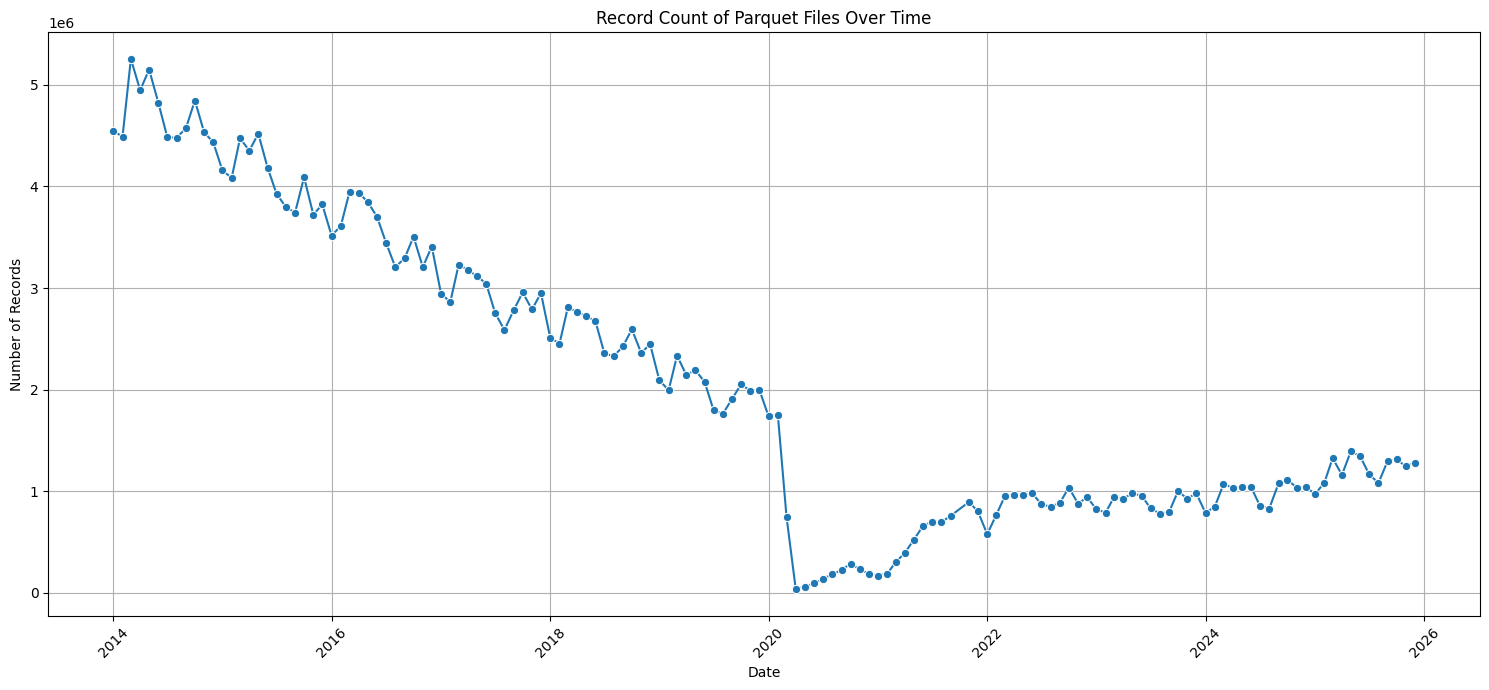

In [ ]:
record_counts = []
for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        df = pd.read_parquet(file_path)
        record_counts.append({
            'File': file_name,
            'Record Count': len(df)
        })
        del df
    except Exception as e:
        print(f"Warning: Could not process {file_name}, error: {e}")

if record_counts:
    record_counts_df = pd.DataFrame(record_counts)
    record_counts_df['YearMonth'] = record_counts_df['File'].str.extract(r'(\d{4}-\d{2})')
    record_counts_df['YearMonth'] = pd.to_datetime(record_counts_df['YearMonth'])
    record_counts_df = record_counts_df.sort_values('YearMonth').reset_index(drop=True)

    print("\nRecord Count:")
    display(record_counts_df)

    plt.figure(figsize=(15, 7))
    sns.lineplot(data=record_counts_df, x='YearMonth', y='Record Count', marker='o')
    plt.title('Record Count')
    plt.xlabel('Date')
    plt.ylabel('Number of Records')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No files processed.")

## pickup and dropoff order consistency

In [4]:
inconsistent_trip_durations = []
for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        df_temp = pd.read_parquet(file_path, columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

        df_temp['tpep_pickup_datetime'] = pd.to_datetime(df_temp['tpep_pickup_datetime'])
        df_temp['tpep_dropoff_datetime'] = pd.to_datetime(df_temp['tpep_dropoff_datetime'])

        inconsistent_records = df_temp[df_temp['tpep_dropoff_datetime'] < df_temp['tpep_pickup_datetime']]

        if not inconsistent_records.empty:
            inconsistent_trip_durations.append({
                'File': file_name,
                'Nr Inconsistent Records': len(inconsistent_records),
                'Percentage of Inconsistent Records': (len(inconsistent_records) / len(df_temp)) * 100
            })
        del df_temp
    except Exception as e:
        print(f"Warning: Could not process {file_name}")

if inconsistent_trip_durations:
    inconsistency_df = pd.DataFrame(inconsistent_trip_durations)
    print("\nInconsistencies found")
    display(inconsistency_df)

    print("\nTop 10 Files with Highest Percentage of Inconsistent Records:")
    top_proportions_df = inconsistency_df.sort_values(by='Percentage of Inconsistent Records', ascending=False).head(10)
    display(top_proportions_df)

    print("Inconsistencies found.")
else:
    print("\nNo Inconsistencies found.")


Inconsistencies found


,File,Nr Inconsistent Records,Percentage of Inconsistent Records
0,yellow_tripdata_2014-01.parquet,177,0.003890
1,yellow_tripdata_2014-02.parquet,156,0.003476
2,yellow_tripdata_2014-03.parquet,225,0.004280
3,yellow_tripdata_2014-04.parquet,159,0.003214
4,yellow_tripdata_2014-05.parquet,186,0.003610
...,...,...,...
107,yellow_tripdata_2025-03.parquet,14,0.001057
108,yellow_tripdata_2025-04.parquet,19,0.001638
109,yellow_tripdata_2025-05.parquet,14,0.001004
110,yellow_tripdata_2025-06.parquet,24,0.001789



Top 10 Files with Highest Percentage of Inconsistent Records:


,File,Nr Inconsistent Records,Percentage of Inconsistent Records
63,yellow_tripdata_2021-01.parquet,601,0.358290
64,yellow_tripdata_2021-02.parquet,645,0.342981
61,yellow_tripdata_2020-11.parquet,627,0.273807
62,yellow_tripdata_2020-12.parquet,455,0.242475
65,yellow_tripdata_2021-03.parquet,621,0.206195
60,yellow_tripdata_2020-10.parquet,446,0.156017
59,yellow_tripdata_2020-09.parquet,314,0.141334
111,yellow_tripdata_2025-11.parquet,1433,0.115237
103,yellow_tripdata_2024-11.parquet,1014,0.098144
83,yellow_tripdata_2022-11.parquet,789,0.090094


Inconsistencies found.


##duplicates

In [ ]:
duplicate_records_info = []

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        df_temp = pd.read_parquet(file_path)
        total_records = len(df_temp)
        num_duplicates = df_temp.duplicated().sum()

        if num_duplicates > 0:
            percentage_duplicates = (num_duplicates / total_records) * 100
            duplicate_records_info.append({
                'File': file_name,
                'Total Records': total_records,
                'Number of Duplicates': num_duplicates,
                'Percentage of Duplicates': percentage_duplicates
            })

        del df_temp

    except Exception as e:
        print(f"Warning: Could not process {file_name} for duplicate check, error: {e}")

if duplicate_records_info:
    duplicates_df = pd.DataFrame(duplicate_records_info)
    print("\nDuplicate Records Found")
    display(duplicates_df)

    total_all_duplicates = duplicates_df['Number of Duplicates'].sum()
    total_files_with_duplicates = len(duplicates_df)

    print(f"Total Duplicate Records: {total_all_duplicates}")
    print(f"Total Files with Duplicates: {total_files_with_duplicates}")

    top_files_with_duplicates = duplicates_df.sort_values(
        by='Percentage of Duplicates', ascending=False
    ).head(10)
    print("\nTop 10 Files:")
    display(top_files_with_duplicates)

else:
    print("\nNo duplicates")

Checking for duplicate records within each file...

--- Duplicate Records Found ---


,File,Total Records,Number of Duplicates,Percentage of Duplicates
0,yellow_tripdata_2014-01.parquet,4550300,34,0.000747
1,yellow_tripdata_2014-02.parquet,4488391,29,0.000646
2,yellow_tripdata_2014-03.parquet,5256647,41,0.000780
3,yellow_tripdata_2014-04.parquet,4947535,47,0.000950
4,yellow_tripdata_2014-05.parquet,5151841,39,0.000757
5,yellow_tripdata_2014-06.parquet,4821908,26,0.000539
6,yellow_tripdata_2014-07.parquet,4483303,35,0.000781
7,yellow_tripdata_2014-08.parquet,4480101,1,0.000022
8,yellow_tripdata_2014-10.parquet,4846346,1,0.000021
9,yellow_tripdata_2014-11.parquet,4532114,10,0.000221



--- Summary of Duplicate Records ---
Total Duplicate Records found across all files: 2183
Total Files with Duplicates: 21

Top 10 Files with Highest Percentage of Duplicates:


,File,Total Records,Number of Duplicates,Percentage of Duplicates
18,yellow_tripdata_2020-01.parquet,1737021,1763,0.101496
17,yellow_tripdata_2018-10.parquet,2594690,144,0.005550
19,yellow_tripdata_2020-06.parquet,91009,1,0.001099
3,yellow_tripdata_2014-04.parquet,4947535,47,0.000950
6,yellow_tripdata_2014-07.parquet,4483303,35,0.000781
2,yellow_tripdata_2014-03.parquet,5256647,41,0.000780
4,yellow_tripdata_2014-05.parquet,5151841,39,0.000757
0,yellow_tripdata_2014-01.parquet,4550300,34,0.000747
1,yellow_tripdata_2014-02.parquet,4488391,29,0.000646
5,yellow_tripdata_2014-06.parquet,4821908,26,0.000539


## numerical outliers

In [5]:
numerical_columns_to_check = [
    'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'airport_fee'
]

all_zscore_outliers = []

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        schema = pq.read_schema(file_path)
        file_present_numerical_cols = [col for col in numerical_columns_to_check if col in schema.names]

        if not file_present_numerical_cols:
            continue

        df_temp = pd.read_parquet(file_path, columns=file_present_numerical_cols)
        total_records_in_file = len(df_temp)

        if total_records_in_file == 0:
            del df_temp
            continue

        for col in file_present_numerical_cols:
            series = df_temp[col].dropna()
            if series.empty or len(series) < 2:
                continue

            # Z-score
            if series.std() > 0:
                z_scores = np.abs(zscore(series))
                num_zscore_outliers = len(z_scores[z_scores > 3])

                if num_zscore_outliers > 0:
                    all_zscore_outliers.append({
                        'File': file_name,
                        'Column': col,
                        'Z-score Outlier Count (>|3|)': num_zscore_outliers,
                        'Percentage Z-score Outliers (of file)': (num_zscore_outliers / total_records_in_file) * 100
                    })
        del df_temp

    except Exception as e:
        print(f"Could not process {file_name} for advanced outlier analysis, error: {e}")

if all_zscore_outliers:
    zscore_outliers_df = pd.DataFrame(all_zscore_outliers)
    print("\nZ-score Outliers (>|3|)")
    display(zscore_outliers_df.sort_values(by='Percentage Z-score Outliers (of file)', ascending=False))

    print("\nOutlier Summary")
    zscore_summary = zscore_outliers_df.groupby('Column').agg(
        TotalZscoreOutliers=('Z-score Outlier Count (>|3|)', 'sum'),
        NumFilesAffected=('File', 'nunique'),
        AvgPercentageZscoreOutliers=('Percentage Z-score Outliers (of file)', 'mean')
    ).sort_values(by='TotalZscoreOutliers', ascending=False)
    display(zscore_summary)
else:
    print("\nNo outliers.")


Z-score Outliers (>|3|)


,File,Column,Z-score Outlier Count (>|3|),Percentage Z-score Outliers (of file)
968,yellow_tripdata_2022-07.parquet,airport_fee,80630,9.249286
593,yellow_tripdata_2019-06.parquet,congestion_surcharge,189187,9.106119
1012,yellow_tripdata_2022-11.parquet,airport_fee,78183,8.927527
1023,yellow_tripdata_2022-12.parquet,airport_fee,83435,8.862572
990,yellow_tripdata_2022-09.parquet,airport_fee,78347,8.849599
...,...,...,...,...
482,yellow_tripdata_2018-07.parquet,fare_amount,1,0.000042
19,yellow_tripdata_2014-03.parquet,trip_distance,2,0.000038
320,yellow_tripdata_2017-01.parquet,fare_amount,1,0.000034
326,yellow_tripdata_2017-01.parquet,total_amount,1,0.000034



Outlier Summary


,TotalZscoreOutliers,NumFilesAffected,AvgPercentageZscoreOutliers
Column,,,
tolls_amount,12193463,143,4.581931
passenger_count,8823532,143,2.973423
tip_amount,5356374,143,1.875509
total_amount,5264392,143,1.896562
fare_amount,5047590,143,1.646346
extra,4766270,143,1.349187
trip_distance,3536773,143,0.940372
mta_tax,2523434,143,1.318688
congestion_surcharge,2520172,83,2.146678


## zero value anomalies

In [ ]:
zero_value_anomalies = []

local_files_directory = '/content/drive/MyDrive/MITBDS/parquet_files_prepared'
parquet_files_paths = glob.glob(os.path.join(local_files_directory, 'yellow_tripdata_*.parquet'))
parquet_files_paths = sorted(parquet_files_paths)

numerical_columns_to_check_for_zeros = [
    'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'airport_fee'
]

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    year_month_match = re.search(r'\d{4}-\d{2}', file_name)
    period = year_month_match.group(0) if year_month_match else 'Unknown'

    try:
        schema = pq.read_schema(file_path)
        file_present_numerical_cols = [col for col in numerical_columns_to_check_for_zeros if col in schema.names]

        if not file_present_numerical_cols:
            continue

        df_temp = pd.read_parquet(file_path, columns=file_present_numerical_cols)
        total_records_in_file = len(df_temp)

        if total_records_in_file == 0:
            del df_temp
            continue

        for col in file_present_numerical_cols:
            zero_count = (df_temp[col] == 0).sum()

            if zero_count > 0:
                percentage_zero = (zero_count / total_records_in_file) * 100
                zero_value_anomalies.append({
                    'File': file_name,
                    'Period': period,
                    'Column': col,
                    'Zero Count': zero_count,
                    'Percentage Zero': percentage_zero
                })
        del df_temp

    except Exception as e:
        print(f"Could not process {file_name} for zero value anomaly analysis, error: {e}")

if zero_value_anomalies:
    zero_anomalies_df = pd.DataFrame(zero_value_anomalies)
    zero_anomalies_df = zero_anomalies_df.sort_values(by=['Period', 'Column']).reset_index(drop=True)

    print("\nZero Value Anomalies (Count and Percentage of records with 0 value):")
    display(zero_anomalies_df)

    print("\nSummary of Zero Value Anomalies:")
    summary_zero_anomalies = zero_anomalies_df.groupby('Column').agg(
        TotalZeroCount=('Zero Count', 'sum'),
        NumFilesAffected=('File', 'nunique'),
        AvgPercentageZero=('Percentage Zero', 'mean')
    ).sort_values(by='TotalZeroCount', ascending=False)
    display(summary_zero_anomalies)



Zero Value Anomalies (Count and Percentage of records with 0 value):


,File,Period,Column,Zero Count,Percentage Zero
0,yellow_tripdata_2014-01.parquet,2014-01,congestion_surcharge,1,0.000022
1,yellow_tripdata_2014-01.parquet,2014-01,extra,80327,1.765312
2,yellow_tripdata_2014-01.parquet,2014-01,improvement_surcharge,4550297,99.999934
3,yellow_tripdata_2014-01.parquet,2014-01,mta_tax,17583,0.386414
4,yellow_tripdata_2014-01.parquet,2014-01,passenger_count,86,0.001890
...,...,...,...,...,...
1379,yellow_tripdata_2025-12.parquet,2025-12,passenger_count,3671,0.286622
1380,yellow_tripdata_2025-12.parquet,2025-12,tip_amount,594301,46.401381
1381,yellow_tripdata_2025-12.parquet,2025-12,tolls_amount,1202728,93.905681
1382,yellow_tripdata_2025-12.parquet,2025-12,total_amount,131,0.010228



Summary of Zero Value Anomalies:


,TotalZeroCount,NumFilesAffected,AvgPercentageZero
Column,,,
tolls_amount,284687649,143,94.943050
tip_amount,103782181,143,32.894285
improvement_surcharge,38544687,141,5.789442
airport_fee,14881442,25,74.306276
extra,14809262,143,8.330038
congestion_surcharge,7020348,84,8.572921
trip_distance,2593840,143,1.233696
mta_tax,1692049,143,0.757712
passenger_count,1338501,143,0.854636


## data type consistency

In [6]:
column_data_types = {}
inconsistent_columns_types = {}
files_processed = 0

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        schema = pq.read_schema(file_path)
        files_processed += 1

        for field in schema:
            col_name = field.name
            col_type = str(field.type)

            if col_name not in column_data_types:
                column_data_types[col_name] = set()
            column_data_types[col_name].add(col_type)

    except Exception as e:
        print(f"Could not read schema for {file_name}, error: {e}")

print("\nSummary of Data Type Consistency:")
for col_name, types_set in column_data_types.items():
    if len(types_set) > 1:
        inconsistent_columns_types[col_name] = sorted(list(types_set))

if inconsistent_columns_types:
    print("\nInconsistencies for the following columns:")
    for col_name, types in inconsistent_columns_types.items():
        print(f"- Column '{col_name}': Found types {types}")

else:
    print("\nAll consistent data types.")

print(f"\nProcessed {files_processed} files for data type consistency.")


Summary of Data Type Consistency:

All consistent data types.

Processed 143 files for data type consistency.


In [3]:
column_data_types_before = {}
files_processed_before = 0

local_files_directory = '/content/drive/MyDrive/MITBDS/parquet_files_prepared'
parquet_files_paths = sorted(glob.glob(os.path.join(local_files_directory, 'yellow_tripdata_*.parquet')))

numerical_columns_for_distribution_check = [
    'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'airport_fee'
]
distribution_stats_before = []

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        schema = pq.read_schema(file_path)
        files_processed_before += 1


        for field in schema:
            col_name = field.name
            col_type = str(field.type)
            if col_name not in column_data_types_before:
                column_data_types_before[col_name] = set()
            column_data_types_before[col_name].add(col_type)


        file_present_numerical_cols = [col for col in numerical_columns_for_distribution_check if col in schema.names]
        if file_present_numerical_cols:
            df_temp = pd.read_parquet(file_path, columns=file_present_numerical_cols)
            for col in file_present_numerical_cols:
                series = df_temp[col].dropna()
                if not series.empty:
                    # Suppress RuntimeWarning for precision loss, as it's not a critical error for the user's current request
                    with np.errstate(invalid='ignore'):
                        distribution_stats_before.append({
                            'File': file_name,
                            'Column': col,
                            'Skewness': skew(series),
                            'Kurtosis': kurtosis(series)
                        })
            del df_temp

    except Exception as e:
        print(f"Could not read schema or data for {file_name} for distribution analysis, error: {e}")

inconsistent_columns_types_before = {}
for col_name, types_set in column_data_types_before.items():
    if len(types_set) > 1:
        inconsistent_columns_types_before[col_name] = sorted(list(types_set))

if inconsistent_columns_types_before:
    print("\nFound data type inconsistencies BEFORE conversion:")
    for col_name, types in inconsistent_columns_types_before.items():
        print(f"- Column '{col_name}': Found types {types}")
else:
    print("\nAll common columns found across the files have consistent data types BEFORE conversion.")

if distribution_stats_before:
    distribution_df_before = pd.DataFrame(distribution_stats_before)
    print("\nDistribution Statistics (Skewness & Kurtosis) BEFORE Type Conversion")
    display(distribution_df_before.groupby('Column').agg(
        AvgSkewness=('Skewness', 'mean'),
        AvgKurtosis=('Kurtosis', 'mean'),
        NumFilesAffected=('File', 'nunique')
    ).sort_values(by='AvgSkewness', ascending=False))
else:
    print("\nNo numerical columns identified.")

print(f"\nProcessed {files_processed_before} files for data type consistency and distribution analysis.")

/tmp/ipykernel_171/1737138111.py:47: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Skewness': skew(series),
/tmp/ipykernel_171/1737138111.py:48: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Kurtosis': kurtosis(series)
/tmp/ipykernel_171/1737138111.py:47: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Skewness': skew(series),
/tmp/ipykernel_171/1737138111.py:48: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Kurtosis': kurtosis(series)



All common columns found across the files have consistent data types BEFORE conversion.

Distribution Statistics (Skewness & Kurtosis) BEFORE Type Conversion


,AvgSkewness,AvgKurtosis,NumFilesAffected
Column,,,
trip_distance,448.243620,479463.615888,143
fare_amount,275.437956,446279.061664,143
total_amount,269.419133,440727.297344,143
extra,163.312584,283203.526846,143
mta_tax,83.322534,92722.637254,143
tolls_amount,70.325000,32777.962947,143
tip_amount,17.442872,3231.276951,143
improvement_surcharge,14.648977,35787.776018,142
airport_fee,3.030480,7.839248,25



Processed 143 files for data type consistency and distribution analysis.


In [ ]:
target_types = {
    'VendorID': pd.Int64Dtype(),
    'passenger_count': pd.Int64Dtype(),
    'RatecodeID': pd.Int64Dtype(),
    'PULocationID': pd.Int64Dtype(),
    'DOLocationID': pd.Int64Dtype(),
    'improvement_surcharge': pd.Float64Dtype(),
    'congestion_surcharge': pd.Float64Dtype(),
    'airport_fee': pd.Float64Dtype(),
}

corrected_files_count = 0
for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        df = pd.read_parquet(file_path)
        modified = False
        columns_to_convert_in_file = {}

        for col_name, target_dtype in target_types.items():
            if col_name in df.columns and str(df[col_name].dtype) != str(target_dtype):
                if (isinstance(target_dtype, pd.api.extensions.ExtensionDtype) and 'int' in target_dtype.name) and \
                   (df[col_name].dtype == 'float64' or df[col_name].dtype == 'float32'):
                    if not df[col_name].dropna().apply(lambda x: x.is_integer()).all():
                        print(f"Warning.")
                columns_to_convert_in_file[col_name] = target_dtype


        if columns_to_convert_in_file:
            for col_name, target_dtype in columns_to_convert_in_file.items():
                original_dtype = df[col_name].dtype
                df[col_name] = df[col_name].astype(target_dtype)
                print(f"Converted '{col_name}' in {file_name} from {original_dtype} to {target_dtype}")
                modified = True

        if modified:
            df.to_parquet(file_path, index=False)
            corrected_files_count += 1
        del df
    except Exception as e:
        print(f"Error processing {file_name} during type conversion: {e}")

print(f"\nCorrected {corrected_files_count} files.")


print("\nData Type Consistency Check (AFTER conversion)")
column_data_types_after = {}
files_processed_after = 0

numerical_columns_for_distribution_check = [
    'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'airport_fee'
]
distribution_stats_after = []

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    try:
        schema = pq.read_schema(file_path)
        files_processed_after += 1

        for field in schema:
            col_name = field.name
            col_type = str(field.type)
            if col_name not in column_data_types_after:
                column_data_types_after[col_name] = set()
            column_data_types_after[col_name].add(col_type)

        file_present_numerical_cols = [col for col in numerical_columns_for_distribution_check if col in schema.names]
        if file_present_numerical_cols:
            df_temp = pd.read_parquet(file_path, columns=file_present_numerical_cols)
            for col in file_present_numerical_cols:
                series = df_temp[col].dropna()
                if not series.empty:
                    distribution_stats_after.append({
                        'File': file_name,
                        'Column': col,
                        'Skewness': skew(series),
                        'Kurtosis': kurtosis(series)
                    })
            del df_temp

    except Exception as e:
        print(f"Could not read schema or data for {file_name} , error: {e}")

inconsistent_columns_types_after = {}
for col_name, types_set in column_data_types_after.items():
    if len(types_set) > 1:
        inconsistent_columns_types_after[col_name] = sorted(list(types_set))

if inconsistent_columns_types_after:
    print("\nFound data type inconsistencies AFTER conversion:")
    for col_name, types in inconsistent_columns_types_after.items():
        print(f"- Column '{col_name}': Found types {types}")

else:
    print("\nconsistent data types.")

if distribution_stats_after:
    distribution_df_after = pd.DataFrame(distribution_stats_after)
    print("\nDistribution Statistics (Skewness & Kurtosis) AFTER Type Conversion")
    display(distribution_df_after.groupby('Column').agg(
        AvgSkewness=('Skewness', 'mean'),
        AvgKurtosis=('Kurtosis', 'mean'),
        NumFilesAffected=('File', 'nunique')
    ).sort_values(by='AvgSkewness', ascending=False))
else:
    print("\nNo numerical columns identified for distribution analysis.")

print(f"\nProcessed {files_processed_after} files.")



--- Attempting to Correct Data Type Inconsistencies ---
Converted 'VendorID' in yellow_tripdata_2014-01.parquet from int64 to Int64
Converted 'passenger_count' in yellow_tripdata_2014-01.parquet from int64 to Int64
Converted 'RatecodeID' in yellow_tripdata_2014-01.parquet from int64 to Int64
Converted 'PULocationID' in yellow_tripdata_2014-01.parquet from int64 to Int64
Converted 'DOLocationID' in yellow_tripdata_2014-01.parquet from int64 to Int64
Converted 'improvement_surcharge' in yellow_tripdata_2014-01.parquet from float64 to Float64
Converted 'congestion_surcharge' in yellow_tripdata_2014-01.parquet from float64 to Float64
Converted 'airport_fee' in yellow_tripdata_2014-01.parquet from object to Float64
Converted 'VendorID' in yellow_tripdata_2014-02.parquet from int64 to Int64
Converted 'passenger_count' in yellow_tripdata_2014-02.parquet from int64 to Int64
Converted 'RatecodeID' in yellow_tripdata_2014-02.parquet from int64 to Int64
Converted 'PULocationID' in yellow_tripdat

/tmp/ipykernel_678/3510078663.py:93: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Skewness': skew(series),
/tmp/ipykernel_678/3510078663.py:94: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Kurtosis': kurtosis(series) # Fisher's kurtosis (excess kurtosis)
/tmp/ipykernel_678/3510078663.py:93: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Skewness': skew(series),
/tmp/ipykernel_678/3510078663.py:94: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Kurtosis': kurtosis(series) # Fisher's k


All common columns found across the files now have consistent data types.

--- Distribution Statistics (Skewness & Kurtosis) AFTER Type Conversion ---
Note: For a perfect normal distribution, both Skewness and Kurtosis (excess kurtosis) are 0.


,AvgSkewness,AvgKurtosis,NumFilesAffected
Column,,,
trip_distance,448.243620,479463.615888,143
fare_amount,275.437956,446279.061664,143
total_amount,269.419133,440727.297344,143
extra,163.312584,283203.526846,143
mta_tax,83.322534,92722.637254,143
tolls_amount,70.325000,32777.962947,143
tip_amount,17.442872,3231.276951,143
improvement_surcharge,14.648977,35787.776018,142
airport_fee,3.030480,7.839248,25



Processed 143 files for data type consistency and distribution analysis after conversion.


## geographical representativeness


Geographical Representativeness Analysis (Top Locations):

Top 10 Pickup Locations (Overall):


,Count
PULocationID,
79,15339483
230,11850450
48,11516084
161,10163898
234,10024872
249,10013993
162,8978233
148,8954470
132,8818295



Top 10 Dropoff Locations (Overall):


,Count
DOLocationID,
79,11357546
48,9501879
170,8897466
68,7512666
107,7328343
236,7144808
141,7124199
230,6756673
186,6627874


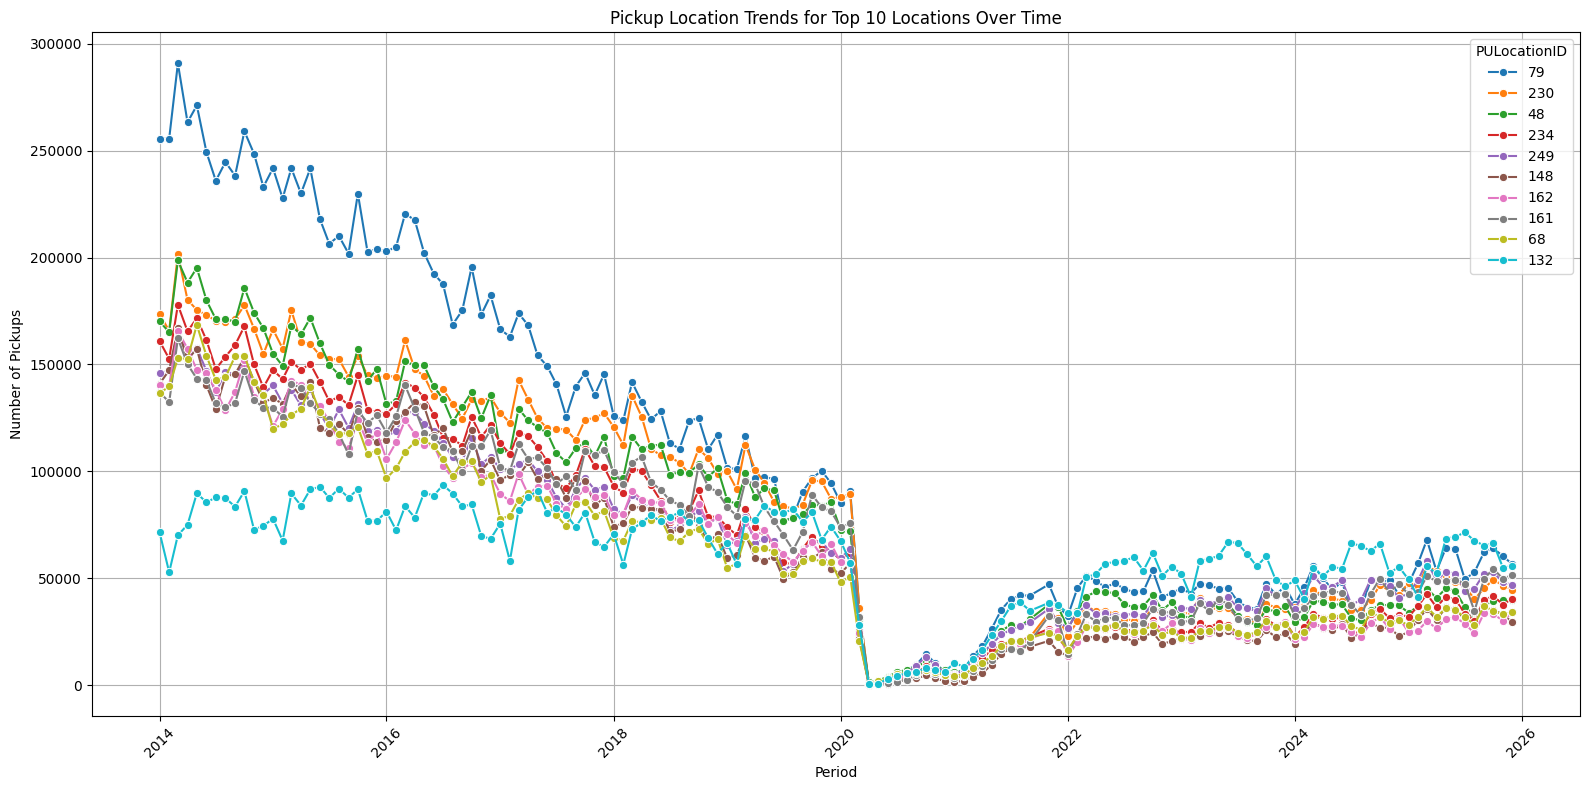

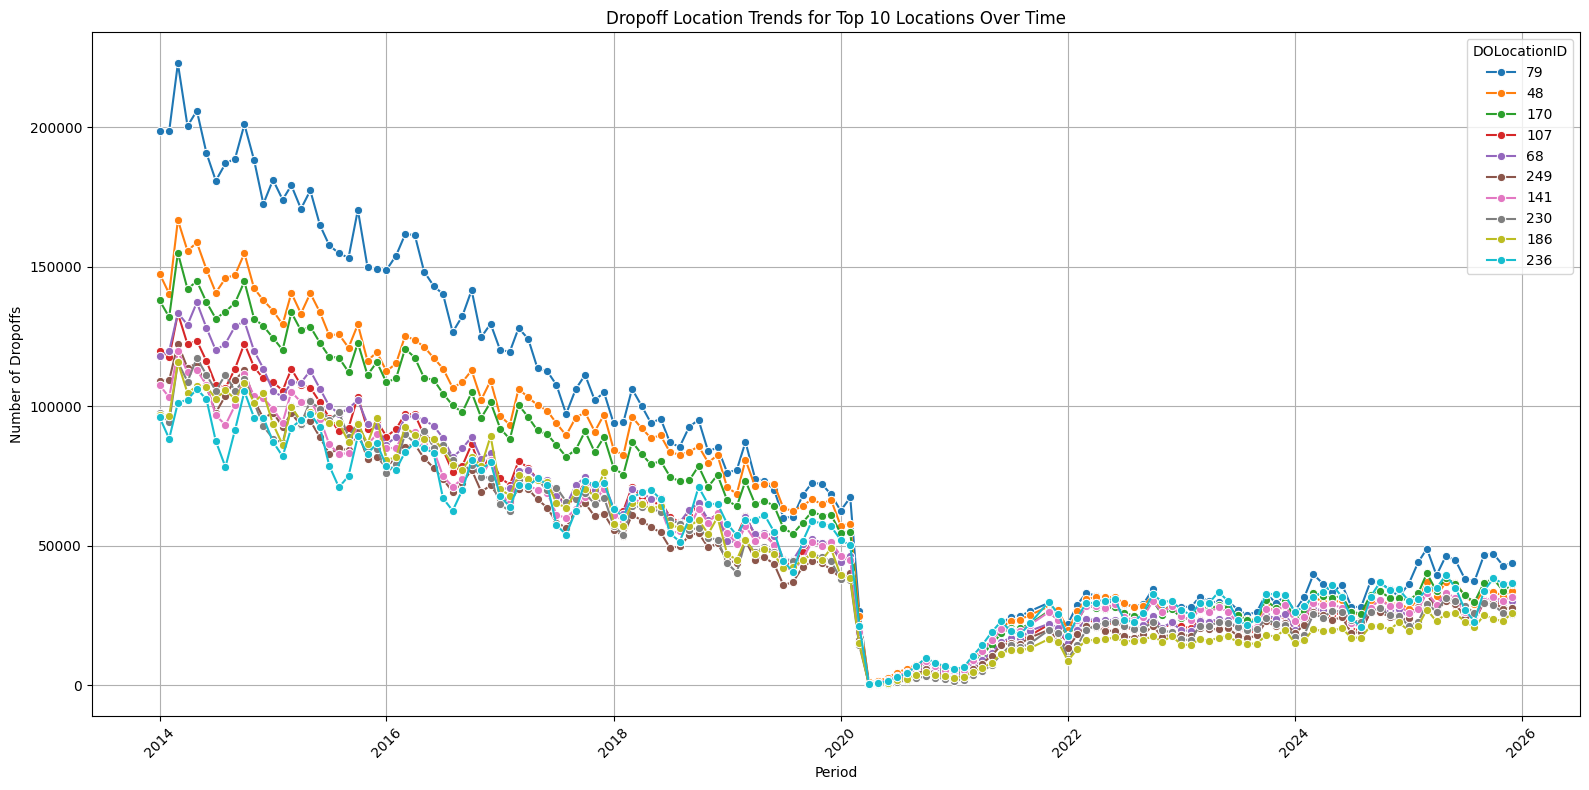

In [ ]:

local_files_directory = '/content/drive/MyDrive/MITBDS/parquet_files'
parquet_files_paths = sorted(glob.glob(os.path.join(local_files_directory, 'yellow_tripdata_*.parquet')))

location_data = []

for file_path in parquet_files_paths:
    file_name = os.path.basename(file_path)
    year_month_match = re.search(r'\d{4}-\d{2}', file_name)
    period = year_month_match.group(0) if year_month_match else 'Unknown'

    try:
        schema = pq.read_schema(file_path)
        cols_to_check = [col for col in ['PULocationID', 'DOLocationID'] if col in schema.names]

        if not cols_to_check:
            continue

        df_temp = pd.read_parquet(file_path, columns=cols_to_check)

        for col in cols_to_check:
            counts = df_temp[col].astype(str).value_counts().reset_index()
            counts.columns = [col, 'Count']
            counts['Type'] = 'Pickup' if col == 'PULocationID' else 'Dropoff'
            counts['File'] = file_name
            counts['Period'] = period
            location_data.append(counts)
        del df_temp

    except Exception as e:
        print(f"Warning: Could not process {file_name} for location ID analysis, error: {e}")

if location_data:
    all_locations_df = pd.concat(location_data, ignore_index=True)
    all_locations_df['Period'] = pd.to_datetime(all_locations_df['Period'])

    print("\nGeographical Representativeness Analysis (Top Locations):")

    # Overall top 10 Pickup Locations
    top_pu_locations = all_locations_df[all_locations_df['Type'] == 'Pickup'] \
                       .groupby('PULocationID')['Count'].sum() \
                       .nlargest(10).index.tolist()

    print("\nTop 10 Pickup Locations (Overall):")
    display(all_locations_df[all_locations_df['Type'] == 'Pickup'] \
            .groupby('PULocationID')['Count'].sum().nlargest(10).to_frame())

    # Overall top 10 Dropoff Locations
    top_do_locations = all_locations_df[all_locations_df['Type'] == 'Dropoff'] \
                       .groupby('DOLocationID')['Count'].sum() \
                       .nlargest(10).index.tolist()

    print("\nTop 10 Dropoff Locations (Overall):")
    display(all_locations_df[all_locations_df['Type'] == 'Dropoff'] \
            .groupby('DOLocationID')['Count'].sum().nlargest(10).to_frame())

    # Plotting trends for top Pickup Locations
    if top_pu_locations:
        plt.figure(figsize=(16, 8))
        sns.lineplot(
            data=all_locations_df[
                (all_locations_df['Type'] == 'Pickup') &
                (all_locations_df['PULocationID'].isin(top_pu_locations))
            ],
            x='Period', y='Count', hue='PULocationID', marker='o'
        )
        plt.title('Pickup Location Trends for Top 10 Locations Over Time')
        plt.xlabel('Period')
        plt.ylabel('Number of Pickups')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Plotting trends for top Dropoff Locations
    if top_do_locations:
        plt.figure(figsize=(16, 8))
        sns.lineplot(
            data=all_locations_df[
                (all_locations_df['Type'] == 'Dropoff') &
                (all_locations_df['DOLocationID'].isin(top_do_locations))
            ],
            x='Period', y='Count', hue='DOLocationID', marker='o'
        )
        plt.title('Dropoff Location Trends for Top 10 Locations Over Time')
        plt.xlabel('Period')
        plt.ylabel('Number of Dropoffs')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

else:
    print("No location ID data found or processed.")